In [1]:
# Import Library for Vision Transformer Deep Learning
from transformers import ViTForImageClassification, ViTFeatureExtractor
from PIL import Image
import requests
import timm
import torch
import torch.optim as optim
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

In [2]:
# Force Device to set to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Current device:", torch.cuda.get_device_name(device))
print(f"Using device: {device}")

Current device: NVIDIA GeForce RTX 3050 Laptop GPU
Using device: cuda


In [3]:
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225]),
])

In [4]:
# Load Dataset Locally
training_dataset = datasets.ImageFolder(root='./new_dataset/Train', transform=transform)
validation_dataset = datasets.ImageFolder(root='./new_dataset/Validation', transform=transform)
test_dataset = datasets.ImageFolder(root='./new_dataset/Test', transform=transform)

In [5]:
# Check the Dataset
print("Training Dataset Size:", len(training_dataset))
print("Validation Dataset Size:", len(validation_dataset))
print("Test Dataset Size:", len(test_dataset))

Training Dataset Size: 35000
Validation Dataset Size: 7500
Test Dataset Size: 7500


In [ ]:
training_loader = DataLoader(training_dataset, batch_size=32, shuffle=True, num_workers=8, pin_memory=True)
validation_loader = DataLoader(validation_dataset, batch_size=32, shuffle=False, num_workers=8, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=8, pin_memory=True)
# Check the DataLoader
print("Training DataLoader Size:", len(training_loader))
print("Validation DataLoader Size:", len(validation_loader))
print("Test DataLoader Size:", len(test_loader))

Training DataLoader Size: 1094
Validation DataLoader Size: 235
Test DataLoader Size: 235


In [7]:
# Load the pre-trained ViT model and feature extractor
model = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=5, drop_rate=0.1, drop_path_rate=0.1).to(device)
model.eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (norm): Identity()


In [8]:
# Optimizer and Loss Function
optimizer = optim.Adam(model.parameters(), lr=3e-4, weight_decay=0.01)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

In [9]:
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm
import time

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=50):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_val_loss = float('inf')
    patience = 10
    trigger_times = 0
    model.to(device)

    # Training Loop
    print("++++Vision Transformer Training Loop++++")
    print("Model Summary:")
    print(f"Number of parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")
    print(f"Number of layers: {len(list(model.children()))}")
    print(f"Device: {device}")
    print("Training Loop is about to start...")
    time.sleep(4)

    for epoch in range(num_epochs):
        model.train()
        start_time = time.time()
        print(f"Epoch {epoch+1}/{num_epochs}")
        # Training
        correct, total = 0, 0
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # Validation
        model.eval()
        correct_val, total_val = 0, 0
        running_val_loss = 0.0
        with torch.no_grad():
            for val_images, val_labels in val_loader:
                val_images, val_labels = val_images.to(device), val_labels.to(device)
                val_outputs = model(val_images)
                val_loss = criterion(val_outputs, val_labels)
                running_val_loss += val_loss.item()
                _, val_preds = torch.max(val_outputs, 1)
                correct_val += (val_preds == val_labels).sum().item()
                total_val += val_labels.size(0)

        # Store metrics in history
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(running_val_loss / len(val_loader))
        history["val_acc"].append(correct_val / total_val)
        
        # Print the metrics for the current epoch
        print(f"Epoch [{epoch+1}/{num_epochs}], "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
              f"Val Loss: {running_val_loss / len(val_loader):.4f}, Val Acc: {correct_val / total_val:.4f}")
        
        # Early Stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            trigger_times = 0
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            trigger_times += 1
            if trigger_times >= patience:
                print("Early stopping triggered due to the overfitting.")
                break
        # Print the time taken for the epoch
        epoch_time = time.time() - start_time
        print(f"Time taken for epoch {epoch+1}: {epoch_time:.2f} seconds")
            
    # print the completion of the training process in epochs and the time taken
    print(f"Training is completed with {epoch+1} epochs.")
    print(f"-=-=-=- Training Results -=-=-=-")
    print(f"Best Accuracy: {max(history['val_acc']):.4f}")
    print(f"Best Loss: {min(history['val_loss']):.4f}")
    # Final metrics
    train_loss = history["train_loss"][-1]
    train_acc = history["train_acc"][-1]
    print("Final Training Metrics:")
    print(f"Final Training Loss: {train_loss:.4f}, Final Training Accuracy: {train_acc:.4f}")
    return model, history
# Train the model and store the history
model, history = train_model(model, training_loader, validation_loader, criterion, optimizer, num_epochs=50)

++++Vision Transformer Training Loop++++
Model Summary:
Number of parameters: 5525381
Number of layers: 9
Device: cuda
Training Loop is about to start...
Epoch 1/50
Epoch [1/50], Train Loss: 0.5785, Train Acc: 0.9187, Val Loss: 0.4561, Val Acc: 0.9825
Time taken for epoch 1: 212.93 seconds
Epoch 2/50
Epoch [2/50], Train Loss: 0.4997, Train Acc: 0.9581, Val Loss: 0.5313, Val Acc: 0.9412
Time taken for epoch 2: 208.17 seconds
Epoch 3/50
Epoch [3/50], Train Loss: 0.4995, Train Acc: 0.9549, Val Loss: 0.4511, Val Acc: 0.9792
Time taken for epoch 3: 209.38 seconds
Epoch 4/50
Epoch [4/50], Train Loss: 0.4845, Train Acc: 0.9621, Val Loss: 0.4330, Val Acc: 0.9853
Time taken for epoch 4: 209.10 seconds
Epoch 5/50
Epoch [5/50], Train Loss: 0.4788, Train Acc: 0.9667, Val Loss: 0.4602, Val Acc: 0.9709
Time taken for epoch 5: 208.98 seconds
Epoch 6/50
Epoch [6/50], Train Loss: 0.4863, Train Acc: 0.9640, Val Loss: 0.4496, Val Acc: 0.9793
Time taken for epoch 6: 207.86 seconds
Epoch 7/50
Epoch [7/50],

In [10]:
model.eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (norm): Identity()


In [11]:
# Testing loop
def test_model(model, test_loader):
    test_history = {
        "test_loss": [],
        "test_acc": []
    }
    print("Testing the model...")

# Set the model to evaluation mode
    model.eval()
    correct, total = 0, 0
    running_test_loss = 0.0
    with torch.no_grad():
        for test_images, test_labels in test_loader:
            test_images, test_labels = test_images.to(device), test_labels.to(device)
            test_outputs = model(test_images)
            loss = criterion(test_outputs, test_labels)
            running_test_loss += loss.item()
            _, test_preds = torch.max(test_outputs, 1)
            correct += (test_preds == test_labels).sum().item()
            total += test_labels.size(0)
    test_loss = running_test_loss / len(test_loader)
    test_acc = correct / total
    test_history["test_loss"].append(test_loss)
    test_history["test_acc"].append(test_acc)
    print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")
    return test_history
# Test the model and store the test history
test_history = test_model(model, test_loader)

Testing the model...
Test Loss: 0.4428, Test Acc: 0.9764


In [12]:
# Performance Metrics
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import seaborn as sns
import pandas as pd

In [13]:
# Evaluate the model
def evaluate_model(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return all_labels, all_preds
# Get predictions and labels
all_labels, all_preds = evaluate_model(model, test_loader)
# Classification Report
print("classification Report:")
print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))
# Collect F1 Score
f1 = f1_score(all_labels, all_preds, average='weighted')
print(f"F1 Score: {f1:.4f}")
# Collect Accuracy Score
accuracy = accuracy_score(all_labels, all_preds)
print(f"Accuracy Score: {accuracy:.4f}")
# Collect the loss Score
loss = test_history["test_loss"][0]
print(f"Loss Score: {loss:.4f}")

classification Report:
              precision    recall  f1-score   support

     Arborio       0.99      0.96      0.98      1500
     Basmati       0.98      0.95      0.96      1500
      Ipsala       1.00      1.00      1.00      1500
     Jasmine       0.95      0.99      0.97      1500
   Karacadag       0.97      0.97      0.97      1500

    accuracy                           0.98      7500
   macro avg       0.98      0.98      0.98      7500
weighted avg       0.98      0.98      0.98      7500

F1 Score: 0.9764
Accuracy Score: 0.9764
Loss Score: 0.4428


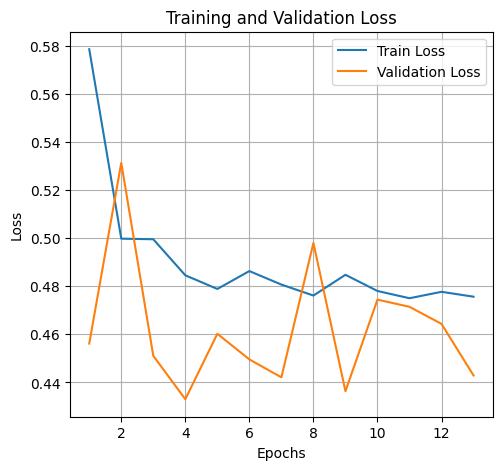

In [14]:
# Plot the History
def plot_history(history):
    import matplotlib.pyplot as plt

    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(12, 5))

    # Plot training and validation loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()
    plt.savefig('loss_plot_dataset_5_class_no_augmentation_new_model.png')
# Plot the training history
plot_history(history)

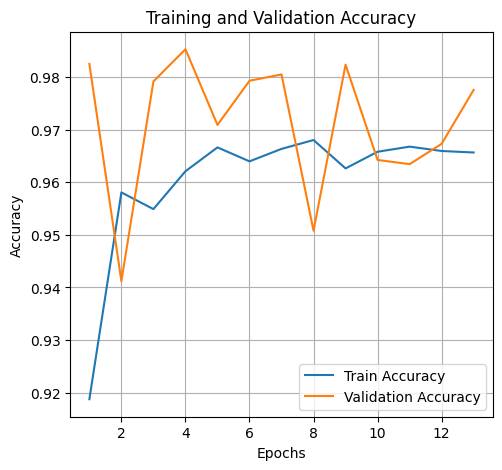

In [15]:
# Plot the History
def plot_history(history):
    import matplotlib.pyplot as plt

    epochs = range(1, len(history['train_acc']) + 1)

    plt.figure(figsize=(12, 5))
    
    # Plot training and validation accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], label='Train Accuracy')
    plt.plot(epochs, history['val_acc'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid()
    plt.savefig('accuracy_plot_dataset_5_no_augmentation_new_model.png')
    plt.show()
    
# Plot the training history
plot_history(history)

In [16]:
# Save the Model
torch.save(model.state_dict(), 'rice_model_vit_5_class_no_augmentation_new_model.pth')